# Image Captioning — Model Prototype

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

In [4]:
!pip install matplotlib timm


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
!pip install mamba-ssm --no-build-isolation


done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp310-cp310-linux_x86_64.whl size=391312244 sha256=14617e2d0c4616ab456823ac8e2903380a17450aba42fd756323c25c00f5e8ae
  Stored in directory: /root/.cache/pip/wheels/80/05/54/c67186c0cb86b4f022575019addc2ccd92514a496f43ce5a1a
Successfully built mamba-ssm

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [7]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from src.models.predict import load_model, load_image, TRANSFORM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.0+cu118
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Device: cuda


In [16]:
!python ../src/data/make_data.py
!python ../src/data/preprocess_annotations.py

Starting data preparation in /workspace/Pattern_Recog_Project/data/ ...

[Flickr8k_Images]
Connecting and downloading...
Downloading... 100%
Download complete!
Extracting to /workspace/Pattern_Recog_Project/data/flickr8k/images/ ...
Removed Flickr8k_Images.zip

[Flickr8k_Text]
Connecting and downloading...
Downloading... 100%
Download complete!
Extracting to /workspace/Pattern_Recog_Project/data/flickr8k/text/ ...
Removed Flickr8k_Text.zip

[MSCOCO_Annotations]
Connecting and downloading...
Downloading... 100%
Download complete!
Extracting to /workspace/Pattern_Recog_Project/data/mscoco/ ...
Removed MSCOCO_Annotations.zip

Data preparation complete!
Processing Flickr8k: /workspace/Pattern_Recog_Project/data/flickr8k/text/Flickr8k.token.txt
Saved 8092 images to /workspace/Pattern_Recog_Project/data/flickr8k_annotations.json
Processing MS COCO: /workspace/Pattern_Recog_Project/data/mscoco/annotations/captions_train2014.json
Saved 82783 images to /workspace/Pattern_Recog_Project/data/msco

## 1. Config

In [8]:
CHECKPOINT  = "../models/best.pt"
ENCODER     = "vit_base"       # vit_base | vit_small | vmamba_small
DECODER     = "transformer"    # transformer | mamba | mamba3
DECODER_DIM = 512
NUM_LAYERS  = 3
MAX_LEN     = 30

## 2. Load model

In [13]:
model, vocab = load_model(
    checkpoint_path=CHECKPOINT,
    encoder_name=ENCODER,
    decoder_name=DECODER,
    vocab_path="../models/vocab.json",       # reads from checkpoint automatically
    decoder_dim=DECODER_DIM,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    device=DEVICE,
)

Loaded checkpoint: ../models/best.pt
  epoch=5  BLEU-4=0.0752  METEOR=0.1464  CIDEr=0.5933
Vocabulary: 4521 tokens  (../models/vocab.json)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Weights loaded.


## 3. Caption a single image

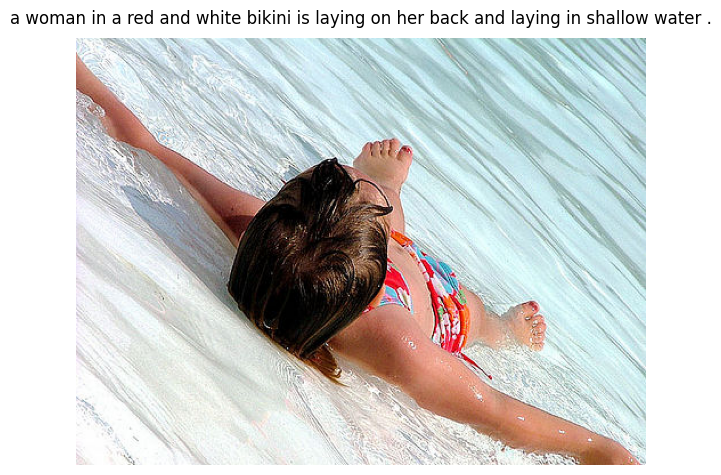

Caption: a woman in a red and white bikini is laying on her back and laying in shallow water .


In [17]:
IMAGE_PATH = "../data/flickr8k/images/Flicker8k_Dataset/667626_18933d713e.jpg"

pil_img = Image.open(IMAGE_PATH).convert("RGB")
tensor  = load_image(IMAGE_PATH).to(DEVICE)
caption = model.generate(tensor, vocab, max_len=MAX_LEN, device=DEVICE)[0]

plt.figure(figsize=(6, 5))
plt.imshow(pil_img)
plt.axis("off")
plt.title(caption, fontsize=12, pad=10)
plt.tight_layout()
plt.show()
print("Caption:", caption)

## 4. Caption multiple images in a grid

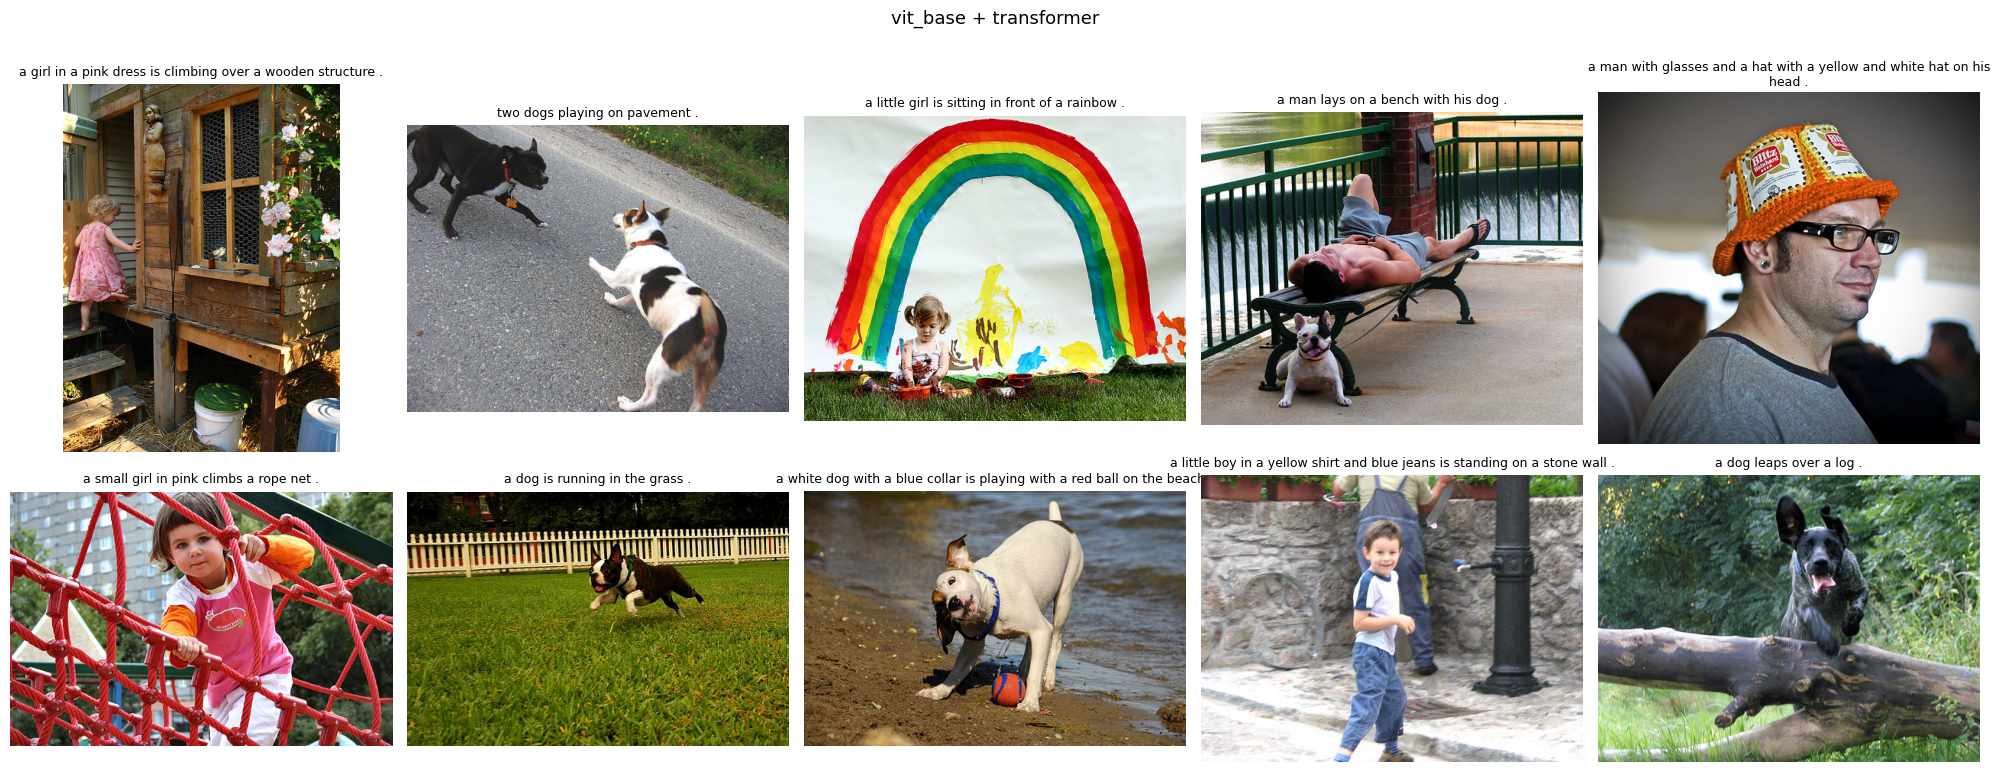

Saved → predictions.png


In [21]:
IMAGE_DIR = "../data/flickr8k/images/Flicker8k_Dataset"
N_IMAGES  = 10
COLS      = 5

exts = {".jpg", ".jpeg", ".png"}
image_paths = [
    str(p) for p in sorted(Path(IMAGE_DIR).iterdir())
    if p.suffix.lower() in exts
][:N_IMAGES]

rows = (len(image_paths) + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 4, rows * 4))
axes = axes.flatten()

for i, path in enumerate(image_paths):
    pil_img = Image.open(path).convert("RGB")
    tensor  = load_image(path).to(DEVICE)
    caption = model.generate(tensor, vocab, max_len=MAX_LEN, device=DEVICE)[0]
    axes[i].imshow(pil_img)
    axes[i].axis("off")
    axes[i].set_title(caption, fontsize=9, wrap=True)

for j in range(len(image_paths), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"{ENCODER} + {DECODER}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("predictions.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved → predictions.png")